В этом задании будет использоваться датасет digits из sklearn.datasets. Оставьте последние 25% объектов для контроля качества, разделив X и y на X_train, y_train и X_test, y_test.

Целью задания будет реализовать самый простой метрический классификатор — метод ближайшего соседа, а также сравнить качество работы реализованного вами 1NN с RandomForestClassifier из sklearn на 1000 деревьях.

In [29]:
from sklearn import datasets, ensemble
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [2]:
digits = datasets.load_digits()

In [4]:
X = digits.data
y = digits.target

In [5]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size = 0.25, shuffle=False)

#### Задание 1

Реализуйте самостоятельно метод одного ближайшего соседа с евклидовой метрикой для задачи классификации. Можно не извлекать корень из суммы квадратов отклонений, т.к. корень — монотонное преобразование и не влияет на результат работы алгоритма.

Никакой дополнительной работы с признаками в этом задании делать не нужно — мы еще успеем этим заняться в других курсах. Ваша реализация может быть устроена следующим образом: можно для каждого классифицируемого объекта составлять список пар (расстояние до точки из обучающей выборки, метка класса в этой точке), затем сортировать этот список (по умолчанию сортировка будет сначала по первому элементу пары, затем по второму), а затем брать первый элемент (с наименьшим расстоянием).

Сортировка массива длиной N требует порядка N log N сравнений (строже говоря, она работает за O(N log N)). Подумайте, как можно легко улучшить получившееся время работы. Кроме простого способа найти ближайший объект всего за N сравнений, можно попробовать придумать, как разбить пространство признаков на части и сделать структуру данных, которая позволит быстро искать соседей каждой точки. За выбор метода поиска ближайших соседей в KNeighborsClassifier из sklearn отвечает параметр algorithm — если у вас уже есть некоторый бэкграунд в алгоритмах и структурах данных, вам может быть интересно познакомиться со структурами данных ball tree и kd tree.

Доля ошибок, допускаемых 1NN на тестовой выборке, — ответ в задании 1.

In [7]:
X_train

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0., 11., ..., 16., 16., 10.],
       [ 0.,  0.,  0., ..., 14.,  1.,  0.],
       [ 0.,  0.,  8., ...,  7.,  0.,  0.]])

In [8]:
y_train

array([0, 1, 2, ..., 2, 6, 3])

In [13]:
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.9622222222222222

<IPython.core.display.Javascript object>


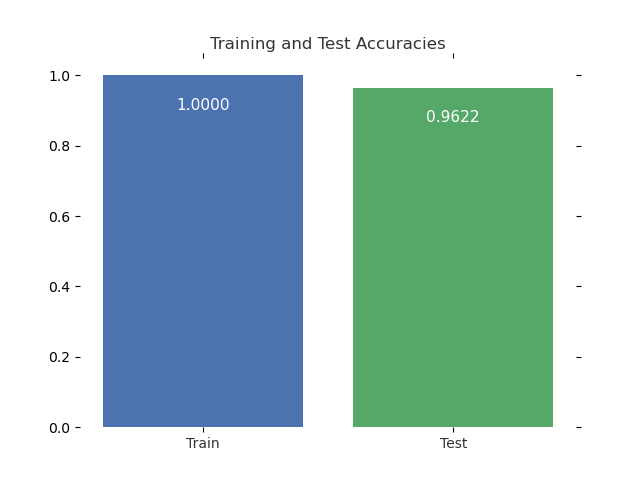

In [35]:
def accuracy_plot():
    import matplotlib.pyplot as plt

    %matplotlib notebook

    scores = [knn.score(X_train, y_train), knn.score(X_test, y_test)]


    plt.figure()

    # Plot the scores as a bar chart
    bars = plt.bar(np.arange(2), scores, color=['#4c72b0','#55a868'])

    # directly label the score onto the bars
    for bar in bars:
        height = bar.get_height()
        plt.gca().text(bar.get_x() + bar.get_width()/2, height*.90, '{0:.{1}f}'.format(height, 4), 
                     ha='center', color='w', fontsize=11)

    # remove all the ticks (both axes), and tick labels on the Y axis
    plt.tick_params(top='off', bottom='off', left='off', right='off', labelleft='off', labelbottom='on')

    # remove the frame of the chart
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    plt.xticks([0,1], ['Train', 'Test'], alpha=0.8);
    plt.title('Training and Test Accuracies', alpha=0.8)
    
accuracy_plot() 

In [25]:
with open("knn_answer1.txt", "w") as fout:
        fout.write(str(1 - knn.score(X_test, y_test)))

#### Задание 2

Теперь обучите на обучающей выборке RandomForestClassifier(n_estimators=1000) из sklearn. Сделайте прогнозы на тестовой выборке и оцените долю ошибок классификации на ней. Эта доля — ответ в задании 2. Обратите внимание на то, как соотносится качество работы случайного леса с качеством работы, пожалуй, одного из самых простых методов — 1NN. Такое различие — особенность данного датасета, но нужно всегда помнить, что такая ситуация тоже может иметь место, и не забывать про простые методы.

In [33]:
clf = ensemble.RandomForestClassifier(n_estimators=1000)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9355555555555556

In [34]:
with open("knn_answer2.txt", "w") as fout:
        fout.write(str(1 - clf.score(X_test, y_test)))